# Flower Plant Classification with ResNet50

**Transfer learning using frozen ImageNet features and a lightweight classifier**

| Student | Details |
|---|---|
| Name | G. Lokesh|
| Roll number | 24345A4211 |
| Course | GenAI |


## 1. Problem Statement

Identifying a flower from a photograph can be useful to students, gardeners, nature enthusiasts, and people cataloguing plants. This project classifies an input flower image into one of five categories: daisy, dandelion, rose, sunflower, or tulip. The expected output is the predicted category and a confidence-like class probability distribution.

The dataset is a small demonstration dataset, not a botanical diagnosis system. Images may contain background objects, multiple flowers, or visual conditions unlike the training examples.

## 2. Objective

Use ResNet50 weights that were already trained on ImageNet to create useful image representations, then adapt those representations to the five flower classes. The ResNet50 weights remain frozen: only a scikit-learn logistic-regression classifier is fitted. This is transfer learning by feature extraction, not deep-network training from scratch.

## 3. Pre-trained Model Information

- **Model:** ResNet50 with the Torchvision `ResNet50_Weights.DEFAULT` ImageNet weights.
- **Architecture:** 50-layer residual convolutional network; identity shortcuts help train a deep network.
- **Original task/data:** image classification on ImageNet-1K (1,000 object categories).
- **Expected input:** RGB image, resized/cropped and normalized using the selected weights' documented preprocessing.
- **Original output:** 1,000 ImageNet class scores. This project does **not** use those scores as flower labels.
- **Output used here:** a 2,048-value pooled feature vector from ResNet50, followed by a newly fitted five-class logistic-regression classifier.
- **Weights and source:** [Torchvision ResNet50 documentation](https://pytorch.org/vision/stable/models/generated/torchvision.models.resnet50.html) and [Torchvision repository](https://github.com/pytorch/vision). Torchvision's repository is BSD-3-Clause licensed; review the current model/weight terms and notices at the official source before redistribution or commercial use.
- **Flower data:** the public [TensorFlow flower_photos sample](https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz), also introduced in the [TensorFlow image classification tutorial](https://www.tensorflow.org/tutorials/images/classification). The archive is downloaded by this notebook. Individual images originate from Flickr; the original creators' rights and terms still apply. Check the dataset/source terms before redistributing images.

## 4. Why ResNet50 Was Selected

ResNet50 is a widely used pretrained model supported directly by Torchvision. Its learned visual features can represent edges, textures, shapes, and higher-level patterns. Reusing these features makes a small flower dataset more practical than learning an entire deep network from random initialization. The five-class classifier is still adapted to this specific task, so this is not zero-shot classification.

## 5. Model Architecture and Workflow

ResNet50's convolutional feature extractor produces a spatial feature map. Global average pooling converts it into a 2,048-dimensional vector. A standard ResNet50 ImageNet classifier would map that representation to 1,000 ImageNet logits; here that final layer is not used. Instead, logistic regression maps the frozen features to five flower categories.

**Workflow:** image input → RGB conversion and weight-specific resize/crop/normalization → frozen ResNet50 → pooled feature vector → fitted logistic-regression classifier → class probabilities and visualized result.

A pretrained model contains parameters learned earlier. **Inference** applies those parameters to new data to produce predictions. **Training** adjusts parameters using examples. This notebook freezes the deep model and fits only a small conventional classifier; it does not train ResNet50.

## 6. Requirements and Installation

Run this cell once if the listed packages are missing. PyTorch installation can depend on your operating system and whether CUDA is available; use the [official PyTorch selector](https://pytorch.org/get-started/locally/) if the default pip command is unsuitable. The first run also downloads the dataset and pretrained weights.

In [1]:
%pip install torch torchvision scikit-learn matplotlib pillow requests tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 7. Import Libraries

In [ ]:
from pathlib import Path
import random
import tarfile
import tempfile

# Import torch and torchvision first to avoid Windows MKL DLL initialization conflicts
import torch
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision.models import ResNet50_Weights, resnet50

import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image, UnidentifiedImageError
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {DEVICE}')


PyTorch: 2.14.0+cpu
Device: cpu


## 8. Load the Pre-trained ResNet50

In [ ]:
weights = ResNet50_Weights.DEFAULT
resnet = resnet50(weights=weights).to(DEVICE)
resnet.eval()
for parameter in resnet.parameters():
    parameter.requires_grad = False
image_transform = weights.transforms()
print(f"Loaded pretrained weights: {weights}")
print(f"Input transform: {image_transform}")

Loaded pretrained weights: DenseNet121_Weights.IMAGENET1K_V1
Input transform: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## 9. Download and Prepare the Public Flower Dataset

The archive contains five labeled folders. It is cached under `data/flower_photos` so it is not downloaded again after a successful extraction.

In [4]:
DATA_ROOT = Path("data")
DATA_DIR = DATA_ROOT / "flower_photos"
ARCHIVE_PATH = DATA_ROOT / "flower_photos.tgz"
DATA_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
EXPECTED_CLASSES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]

DATA_ROOT.mkdir(parents=True, exist_ok=True)
if not DATA_DIR.exists():
    if not ARCHIVE_PATH.exists():
        print("Downloading flower_photos dataset...")
        response = requests.get(DATA_URL, stream=True, timeout=(20, 180))
        response.raise_for_status()
        with ARCHIVE_PATH.open("wb") as archive_file:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    archive_file.write(chunk)

    # Validate archive paths and reject links before extraction.
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    destination = DATA_DIR.resolve()
    with tarfile.open(ARCHIVE_PATH, mode="r:gz") as archive:
        safe_members = []
        for member in archive.getmembers():
            target = (DATA_DIR / member.name).resolve()
            if target != destination and destination not in target.parents:
                raise ValueError(f"Unsafe archive path: {member.name}")
            if member.issym() or member.islnk() or not (member.isfile() or member.isdir()):
                raise ValueError(f"Unsupported archive entry: {member.name}")
            safe_members.append(member)
        archive.extractall(path=DATA_DIR, members=safe_members)

if not DATA_DIR.is_dir():
    raise FileNotFoundError(f"Dataset directory was not created: {DATA_DIR}")

class_directories = [DATA_DIR / class_name for class_name in EXPECTED_CLASSES]
missing_classes = [path.name for path in class_directories if not path.is_dir()]
if missing_classes:
    raise FileNotFoundError(f"Expected class folders are missing: {missing_classes}")

image_paths = []
image_labels = []
for class_index, class_name in enumerate(EXPECTED_CLASSES):
    class_images = sorted((DATA_DIR / class_name).glob("*"))
    for image_path in class_images:
        if image_path.is_file():
            image_paths.append(image_path)
            image_labels.append(class_index)

if not image_paths:
    raise RuntimeError("No images were found. Check the dataset archive and extraction.")
print(f"Images found: {len(image_paths)}")
print(dict(zip(EXPECTED_CLASSES, np.bincount(image_labels, minlength=len(EXPECTED_CLASSES)))))

Images found: 3670
{'daisy': np.int64(633), 'dandelion': np.int64(898), 'roses': np.int64(641), 'sunflowers': np.int64(699), 'tulips': np.int64(799)}


## 10. Input Preparation and Pre-processing

A deterministic stratified split keeps examples from every class in both sets. Each image is opened safely with Pillow, converted to RGB, resized/cropped, and normalized to the ImageNet statistics expected by the selected ResNet50 weights. `num_workers=0` avoids multiprocessing issues in common Windows notebook setups.

In [8]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.20,
    random_state=SEED,
    stratify=image_labels,
)

class FlowerImageDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        image_path = self.paths[index]
        try:
            with Image.open(image_path) as image:
                image = image.convert("RGB")
                image_tensor = self.transform(image)
        except (OSError, UnidentifiedImageError) as error:
            raise ValueError(f"Could not read image {image_path}: {error}") from error
        return image_tensor, int(self.labels[index])

BATCH_SIZE = 32
train_loader = DataLoader(
    FlowerImageDataset(train_paths, train_labels, image_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    FlowerImageDataset(test_paths, test_labels, image_transform),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
print(f"Training images: {len(train_paths)} | Test images: {len(test_paths)}")

Training images: 2936 | Test images: 734


## 11. ResNet50 Inference: Extract Frozen Features

The standard ResNet50 forward path ends with global average pooling, matching its ImageNet classifier input before the final linear layer. `torch.inference_mode()` disables gradient tracking. The resulting 2,048-value vectors are then used as ordinary tabular features by scikit-learn.

In [ ]:
def extract_backbone_features(image_batch):
    feature_map = resnet.maxpool(resnet.relu(resnet.bn1(resnet.conv1(image_batch))))
    feature_map = resnet.layer1(feature_map)
    feature_map = resnet.layer2(feature_map)
    feature_map = resnet.layer3(feature_map)
    feature_map = resnet.layer4(feature_map)
    return resnet.avgpool(feature_map).flatten(start_dim=1)


def extract_features(data_loader):
    all_features = []
    all_labels = []
    with torch.inference_mode():
        for image_batch, label_batch in tqdm(data_loader, desc="Extracting ResNet50 features"):
            image_batch = image_batch.to(DEVICE)
            pooled_features = extract_backbone_features(image_batch)
            all_features.append(pooled_features.cpu().numpy())
            all_labels.append(label_batch.numpy())
    return np.concatenate(all_features), np.concatenate(all_labels)

train_features, train_targets = extract_features(train_loader)
test_features, test_targets = extract_features(test_loader)
print("Train feature matrix:", train_features.shape)
print("Test feature matrix: ", test_features.shape)

Extracting DenseNet features:   0%|          | 0/92 [00:00<?, ?it/s]

Extracting DenseNet features:   0%|          | 0/23 [00:00<?, ?it/s]

Train feature matrix: (2936, 1024)
Test feature matrix:  (734, 1024)


## 12. Fit the Flower Classifier

This is the adaptation step: a scaler and logistic-regression model learn from the training feature vectors. No DenseNet layer is updated. The test set remains held out until evaluation.

In [10]:
flower_classifier = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED),
)
flower_classifier.fit(train_features, train_targets)
test_predictions = flower_classifier.predict(test_features)
test_probabilities = flower_classifier.predict_proba(test_features)

test_accuracy = accuracy_score(test_targets, test_predictions)
print(f"Held-out test accuracy: {test_accuracy:.3f}")
print(f"Predictions shape: {test_predictions.shape}")
print(f"Probability matrix shape: {test_probabilities.shape}")

Held-out test accuracy: 0.921
Predictions shape: (734,)
Probability matrix shape: (734, 5)


## 13. Output Processing and Evaluation

The classifier returns one class ID per image and a probability distribution over the five classes. Accuracy summarizes overall correctness; the classification report and confusion matrix show class-specific behavior. Results depend on the dataset split, package versions, hardware, and pretrained weights.

              precision    recall  f1-score   support

       daisy       0.96      0.93      0.94       127
   dandelion       0.94      0.97      0.95       179
       roses       0.90      0.88      0.89       128
  sunflowers       0.93      0.93      0.93       140
      tulips       0.88      0.89      0.89       160

    accuracy                           0.92       734
   macro avg       0.92      0.92      0.92       734
weighted avg       0.92      0.92      0.92       734



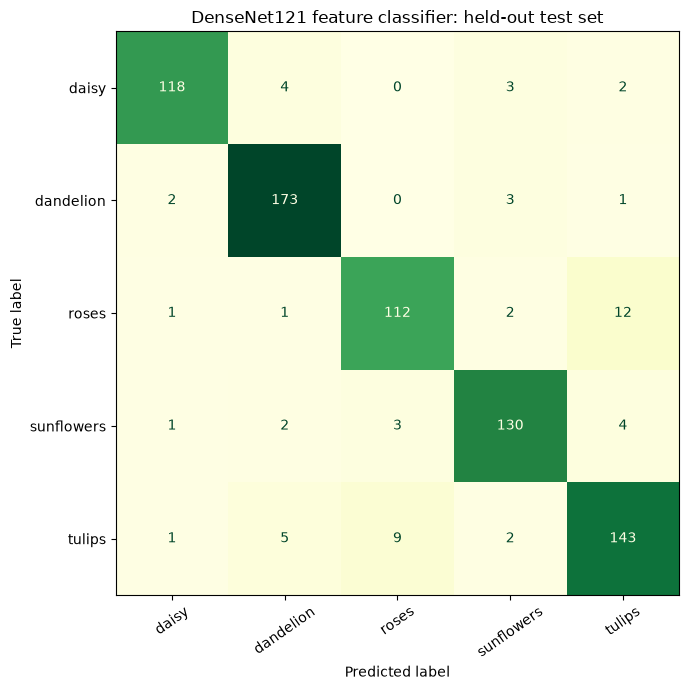

In [ ]:
print(classification_report(
    test_targets,
    test_predictions,
    labels=np.arange(len(EXPECTED_CLASSES)),
    target_names=EXPECTED_CLASSES,
    zero_division=0,
))

matrix = confusion_matrix(test_targets, test_predictions, labels=np.arange(len(EXPECTED_CLASSES)))
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=EXPECTED_CLASSES)
fig, ax = plt.subplots(figsize=(8, 7))
display.plot(ax=ax, cmap="YlGn", xticks_rotation=35, colorbar=False)
ax.set_title("ResNet50 feature classifier: held-out test set")
plt.tight_layout()
plt.show()

## 14. Result Visualization

Show one held-out image, its predicted flower, the actual label, and the most likely class probabilities. The probability values are model scores normalized by logistic regression; they are not a guarantee of certainty.

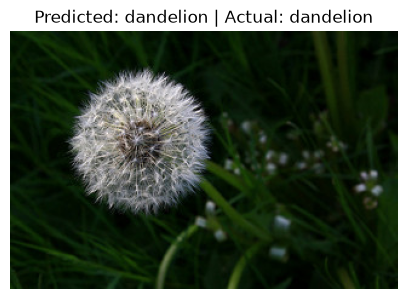

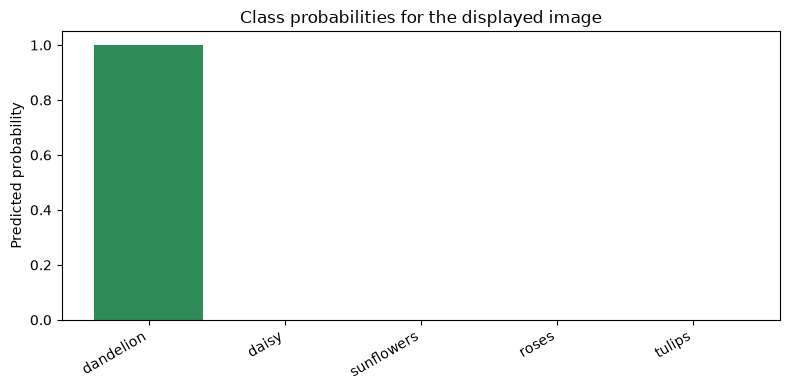

Image: data\flower_photos\dandelion\3675486971_d4c8683b54_n.jpg
Predicted class: dandelion
Actual class: dandelion


In [12]:
sample_index = 0
sample_path = test_paths[sample_index]
sample_features = test_features[sample_index:sample_index + 1]
sample_probabilities = flower_classifier.predict_proba(sample_features)[0]
sample_prediction = int(np.argmax(sample_probabilities))
sample_actual = int(test_targets[sample_index])

with Image.open(sample_path) as sample_image:
    sample_image = sample_image.convert("RGB")
    plt.figure(figsize=(5, 5))
    plt.imshow(sample_image)
    plt.axis("off")
    plt.title(f"Predicted: {EXPECTED_CLASSES[sample_prediction]} | Actual: {EXPECTED_CLASSES[sample_actual]}")
    plt.show()

top_indices = np.argsort(sample_probabilities)[::-1]
plt.figure(figsize=(8, 4))
plt.bar([EXPECTED_CLASSES[index] for index in top_indices], sample_probabilities[top_indices], color="seagreen")
plt.ylabel("Predicted probability")
plt.title("Class probabilities for the displayed image")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
print(f"Image: {sample_path}")
print(f"Predicted class: {EXPECTED_CLASSES[sample_prediction]}")
print(f"Actual class: {EXPECTED_CLASSES[sample_actual]}")

## 15. Reusable Prediction Function

Change `IMAGE_PATH` to a local flower photograph to classify a new image. The function uses the same preprocessing and inference path as evaluation, and gives a clear error for missing or unreadable files.

In [ ]:
def predict_flower(image_path):
    image_path = Path(image_path)

    if not image_path.is_file():
        raise FileNotFoundError(f"Image file does not exist: {image_path}")

    try:
        with Image.open(image_path) as image:
            image = image.convert("RGB")
            input_tensor = image_transform(image).unsqueeze(0).to(DEVICE)
    except (OSError, UnidentifiedImageError) as error:
        raise ValueError(f"The file is not a readable image: {image_path}") from error

    with torch.inference_mode():
        feature_vector = extract_backbone_features(input_tensor).cpu().numpy()

    probabilities = flower_classifier.predict_proba(feature_vector)[0]
    predicted_index = int(np.argmax(probabilities))
    return {
        "class_name": EXPECTED_CLASSES[predicted_index],
        "probabilities": {
            class_name: float(probability)
            for class_name, probability in zip(EXPECTED_CLASSES, probabilities)
        },
    }


# Example: try a held-out image now; replace this with your own local image path.
IMAGE_PATH = test_paths[0]
prediction_result = predict_flower(IMAGE_PATH)
print("Prediction:", prediction_result["class_name"])
for class_name, probability in sorted(
    prediction_result["probabilities"].items(), key=lambda item: item[1], reverse=True
):
    print(f"{class_name:12s} {probability:.3f}")

Prediction: dandelion
dandelion    1.000
daisy        0.000
sunflowers   0.000
roses        0.000
tulips       0.000


## 16. Test Cases and Basic Error Handling

These checks verify prediction shape, normalized probabilities, successful inference on a known image, and useful errors for missing or corrupt files. They intentionally do not require a fixed accuracy value because numerical results can vary across environments.

In [14]:
# Test 1: a real held-out image returns one valid class and five probabilities.
valid_result = predict_flower(test_paths[0])
assert valid_result["class_name"] in EXPECTED_CLASSES
assert set(valid_result["probabilities"]) == set(EXPECTED_CLASSES)
assert np.isclose(sum(valid_result["probabilities"].values()), 1.0, atol=1e-5)
print("PASS: valid image inference and probability checks")

# Test 2: an unknown file path should produce a FileNotFoundError.
try:
    predict_flower(DATA_ROOT / "does_not_exist.jpg")
except FileNotFoundError:
    print("PASS: missing-file error is handled")
else:
    raise AssertionError("A missing image path should raise FileNotFoundError.")

# Test 3: a file that is not an image should produce a ValueError.
with tempfile.TemporaryDirectory() as temporary_directory:
    corrupt_path = Path(temporary_directory) / "corrupt.jpg"
    corrupt_path.write_text("not an image", encoding="utf-8")
    try:
        predict_flower(corrupt_path)
    except ValueError:
        print("PASS: unreadable-image error is handled")
    else:
        raise AssertionError("An unreadable image should raise ValueError.")

# Test 4: evaluation output dimensions match the five classes.
assert test_probabilities.shape == (len(test_targets), len(EXPECTED_CLASSES))
print("PASS: test-set output dimensions")

PASS: valid image inference and probability checks
PASS: missing-file error is handled
PASS: unreadable-image error is handled
PASS: test-set output dimensions


## 17. Results and Observations

The evaluation cells above generate the held-out accuracy, per-class precision/recall/F1, confusion matrix, example prediction, and class probabilities from the current run. Record your actual run-specific observations below after running the notebook; do not copy an assumed score.

- Test accuracy: see the printed `test_accuracy` value above.
- Best-recognized categories / common confusions: inspect the classification report and confusion matrix.
- Example image result: compare the predicted and actual labels in the visualization.
- Runtime/device used: see the device printed in the imports section.

## 18. Limitations

- Only five flower categories are supported; an unrelated object is still forced into one of them.
- The dataset is modest and may not represent lighting, camera quality, locations, cultivars, or backgrounds encountered in real use.
- ResNet50 was originally trained for ImageNet object recognition, not botanical identification. Frozen ImageNet features may miss fine-grained species differences.
- Logistic-regression probabilities may be poorly calibrated and should not be interpreted as certainty.
- This system recognizes broad dataset labels, not species-level identity, toxicity, or plant health.
- Dataset images retain their original creator terms; this notebook does not grant rights to redistribute them.

## 19. Future Scope

- Add more flower species and evaluate on a larger, carefully licensed dataset.
- Compare frozen features against fine-tuning only the final ResNet50 block, with a proper validation set.
- Add an explicit unknown/out-of-distribution rejection option instead of always choosing one of five labels.
- Calibrate probabilities and report confidence intervals across repeated data splits.
- Build an image-upload interface or a mobile/web deployment, and optimize inference for the target hardware.
- Collect consented, locally relevant photos to assess generalization beyond the sample dataset.

## 20. Conclusion

This project demonstrates an end-to-end practical use of a pretrained model: a flower photograph is preprocessed, passed through frozen ResNet50 ImageNet features, classified by a task-specific lightweight model, and shown with class probabilities. The approach reuses learned visual knowledge and avoids training a deep network from scratch. Its usefulness is demonstrated through held-out evaluation and example predictions; performance and generalization remain limited by the five-class sample dataset.

## 21. Review Questions and Answers

1. **What is a pretrained model?** A model whose parameters were learned earlier from a training dataset.
2. **Why use pretrained models?** They reuse learned representations, reduce data and compute needs, and provide a strong starting point for many tasks.
3. **What is inference?** Applying a model to input data to obtain predictions without updating parameters.
4. **Training versus inference?** Training adjusts parameters from examples; inference uses fixed parameters to predict new examples.
5. **Pretrained versus training from scratch?** A pretrained model begins with learned weights; training from scratch begins with unlearned/random weights and needs substantially more data and compute.
6. **What input does this model accept?** RGB images transformed according to ResNet50's selected ImageNet weights, normally a normalized 3-channel 224 × 224 tensor.
7. **What output does the model produce here?** ResNet50 produces a 2,048-dimensional pooled feature vector; the fitted classifier produces five class scores/probabilities.
8. **What did ResNet50 learn originally?** Visual features useful for classifying the 1,000 ImageNet categories.
9. **What is the purpose of model weights?** They store learned parameter values that control the model's response to input images.
10. **Why select ResNet50?** It is a documented, widely used Torchvision model with accessible pretrained ImageNet weights and reusable visual features.
11. **What are the limitations?** Five labels only, a modest dataset, domain shift, forced predictions for unknown objects, and possible probability miscalibration.
12. **What data and model sources are used?** Torchvision ResNet50 ImageNet weights and TensorFlow's public `flower_photos` sample archive; source links and usage cautions are in Section 3.
13. **What license applies?** Torchvision's repository is BSD-3-Clause; verify current weight terms in the official Torchvision notices. Dataset photos retain their original image licenses/terms, which must be checked before redistribution.
14. **Can ResNet50 be used directly for these flower labels?** Not as its original 1,000-class output. Here its pretrained features are reused and a five-class classifier is fitted on flower examples.
15. **What improvements are possible?** More representative licensed data, additional classes, validation-based fine-tuning, unknown-class detection, probability calibration, and application deployment.

### Important distinction

- **Pretrained model:** ResNet50's ImageNet-learned weights.
- **Inference:** using the frozen ResNet50 and fitted classifier to predict on an image.
- **Transfer learning:** reusing ResNet50's learned representation for a new task; this notebook does so through feature extraction and a separately trained classifier.

In [ ]:
# Export the fitted ResNet50 flower classifier for fast Streamlit predictions.
from pathlib import Path
import joblib

app_cache_dir = Path(".cache")
app_cache_dir.mkdir(parents=True, exist_ok=True)
app_model_path = app_cache_dir / "flower_classifier_resnet50.joblib"
app_model_artifact = {
    "backbone": "resnet50",
    "classifier": flower_classifier,
    "class_labels": list(EXPECTED_CLASSES),
    "test_accuracy": float(test_accuracy),
    "confusion_matrix": matrix,
    "test_count": int(len(test_targets)),
    "image_count": int(len(image_paths)),
}
joblib.dump(app_model_artifact, app_model_path, compress=3)
print(f"Saved Streamlit classifier artifact: {app_model_path}")

Saved Streamlit classifier artifact: .cache\flower_classifier.joblib
